In [1]:
import numpy as np
# import seaborn as sns
import pandas as pd
import os.path

import matplotlib.pyplot as plt

import tifffile 
import czifile

from skimage import transform
from scipy import ndimage

import random 
import math

In [2]:
patch_size = 16
major_ch = 1
ctr_or_y = 'y'
ctrl_y_str = ctr_or_y+'_ch'+str(major_ch)+'_major'

seg_folder_str = 'code_org_20250820_seg'
group_str = ctrl_y_str[:-6]+'_PAX_AE_patches_gridonly_wholecell_ps'+str(patch_size)+'_dist_front'



In [3]:
start_ind = 0
end_ind = 51

if(ctr_or_y=='ctrl'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Control'
if(ctr_or_y=='y'):
    image_folder = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/Ycomp'
        

In [4]:
seg_folder_str = 'code_org_20250820_seg'

cell_mask_folder = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'+ctrl_y_str+'/'+seg_folder_str+'/mask'

front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/frontmasks'

In [5]:
half_ps = int(patch_size/2)
half_half_ps = int(patch_size/4)
double_ps = patch_size*2
double_double_ps = patch_size*4

In [6]:
def rotate_coor(x_i,y_i,x_c,y_c,rotate_angle):
 
    rotate_angle = rotate_angle*np.pi/180
 
    x_o = (x_i-x_c)*math.cos(rotate_angle) - (2*y_c-y_i-y_c)*math.sin(rotate_angle) +x_c
    y_o = -(x_i-x_c)*math.sin(rotate_angle) - (2*y_c-y_i-y_c)*math.cos(rotate_angle) +(2*y_c-y_c)

    return([x_o,y_o])

In [7]:
from datetime import datetime
now = datetime.now()

time_str = now.strftime("%Y%m%d_%H%M")

In [8]:
mask_ratio = 0.4
movie_partitioned_data_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'\
    +ctrl_y_str+'/'+group_str+ '/tiff_patches'+str(patch_size)+'_40p_'+time_str
movie_plot_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/' \
    +ctrl_y_str+'/'+group_str+ '/plot_patches'+str(patch_size)+'_40p_'+time_str
os.makedirs(movie_partitioned_data_dir,exist_ok=True)
os.makedirs(movie_plot_dir,exist_ok=True)


In [9]:
data_prep_record = pd.DataFrame(columns=['image_folder','filename','filenameID','x_c','y_c','rand_angle','rand_tx','rand_ty',
                            'x_corner1','x_corner2','x_corner3','x_corner4','y_corner1','y_corner2','y_corner3','y_corner4',
                            'movie_partitioned_data_dir','crop_img_filename','movie_plot_dir','plot_filename',
                            'dist_cell_edge','front_flag'])

In [10]:
from skimage.feature import peak_local_max



In [11]:
def image_padding(input_img, pad_size,value):
    output_img = np.zeros([input_img.shape[0]+pad_size*2,input_img.shape[1]+pad_size*2]) + value
    output_img[pad_size:input_img.shape[0]+pad_size,pad_size:input_img.shape[1]+pad_size] = input_img
    return output_img

In [12]:
from scipy.ndimage import distance_transform_cdt

In [13]:
import os
import numpy as np
import czifile
import tifffile

filenames = [
    x for x in os.listdir(image_folder)
    if os.path.isfile(os.path.join(image_folder, x)) and ('.czi' in x)
]

all_pixel_data = []   # collect per-image arrays here

for filenameID in range(start_ind, min(end_ind, len(filenames))):

    filename = filenames[filenameID]
    print("Processing:", filename)

    # -----------------------------
    # 1. Load multi-channel image
    # -----------------------------
    train_img = czifile.imread(os.path.join(image_folder, filename))

    # Shape of CZI is often (1,1,Channels,Y,X) or (Channels,Y,X)
    train_img = np.squeeze(train_img)   # remove singleton dims

    if train_img.ndim == 2:
        raise ValueError("Image has only 1 channel, expected 4 channels.")

    # Expected shape → (C, H, W)
    if train_img.shape[0] < train_img.shape[-1]:
        num_channels = train_img.shape[0]
        H, W = train_img.shape[1], train_img.shape[2]
    else:
        # fallback if C is last (unlikely for czi)
        train_img = np.moveaxis(train_img, -1, 0)
        num_channels = train_img.shape[0]
        H, W = train_img.shape[1], train_img.shape[2]

    # ---------------------------------
    # 2. Load masks (same spatial size)
    # ---------------------------------
    cell_mask = tifffile.imread(
        os.path.join(cell_mask_folder, "cell_mask_" + filename + ".tif")
    ).squeeze().astype(float)

    front_mask = tifffile.imread(
        os.path.join(front_mask_dir, 'frontmask-' + filename[:-4] + '.tif')
    ).squeeze().astype(float)/255
    front_mask = front_mask*cell_mask

    # ---------------------------------
    # 3. Flatten everything per-pixel
    # ---------------------------------
    # Flatten channels → each becomes (H*W,)
    ch_flat = [train_img[ch].reshape(-1) for ch in range(num_channels)]

    # flatten masks
    cell_flat  = cell_mask.reshape(-1)
    front_flat = front_mask.reshape(-1)

    # Stack columns: [ch1, ch2, ch3, ch4, cell_flag, front_flag]
    pixel_matrix = np.column_stack(ch_flat + [cell_flat, front_flat])

    # Append
    all_pixel_data.append(pixel_matrix)

# -------------------------------------
# 4. Concatenate all images’ pixel rows
# -------------------------------------
all_pixel_data = np.concatenate(all_pixel_data, axis=0)

print("Final pixel matrix shape:", all_pixel_data.shape)
# → (N_total_pixels, 4 + 2)


Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-01.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-02.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-03.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-04.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-05.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-06.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-07.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-08.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-09.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-10.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-11.czi
Processing: eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568_ycomp-12.czi
Proc

/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)
/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)
/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)
/tmp/ipykernel_531158/4173525782.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support fo

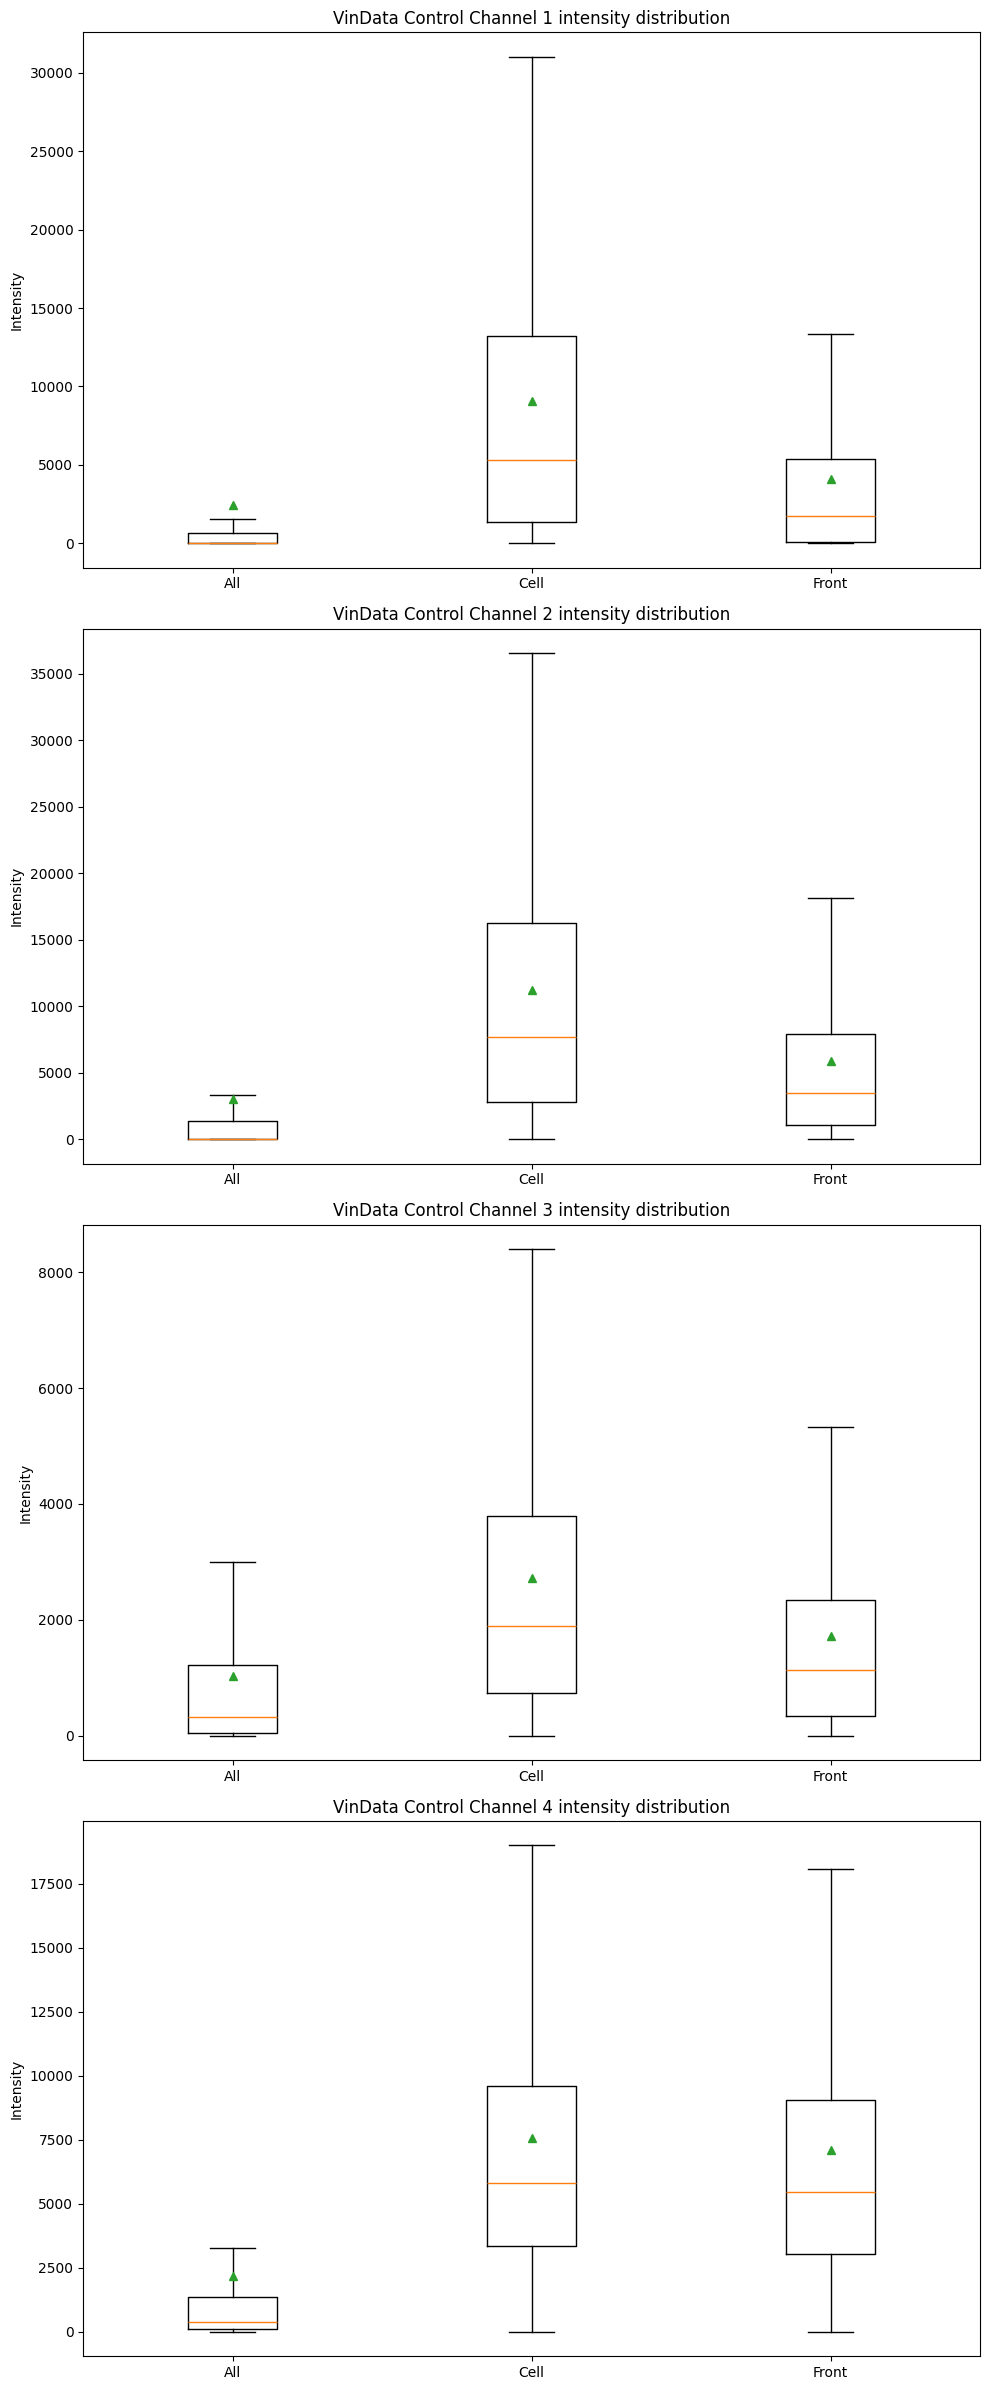

In [17]:
import matplotlib.pyplot as plt
import numpy as np

num_channels = 4

cell_idx  = all_pixel_data[:, 4] > 0
front_idx = all_pixel_data[:, 5] > 0

fig, axes = plt.subplots(num_channels, 1, figsize=(10, 3*2*num_channels))

if num_channels == 1:
    axes = [axes]  # ensure iterable

for ch in range(num_channels):

    ch_all   = all_pixel_data[:, ch]
    ch_cell  = all_pixel_data[cell_idx, ch]
    ch_front = all_pixel_data[front_idx, ch]

    data = [ch_all[::10], ch_cell[::10], ch_front[::10]]
    labels = ["All", "Cell", "Front"]

    ax = axes[ch]

    
    ax.boxplot(data, labels=labels, showmeans=True, showfliers=False)

    # # Optional: adjust violin colors
    # for pc in parts['bodies']:
    #     pc.set_alpha(0.6)

    ax.set_title(f"VinData Control Channel {ch+1} intensity distribution")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(labels)
    ax.set_ylabel("Intensity")

plt.tight_layout()
plt.show()


In [18]:
data[1].shape

(2670263,)

In [19]:
data[0].shape

(10747904,)

In [20]:
filenames = [x for x in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, x)) and ('.czi' in x)]

debug_flag = 0

for filenameID in range(start_ind, min(end_ind,len(filenames))):
# for filenameID in range(0,1):
    if debug_flag ==1:
                break
    filename = filenames[filenameID]
    train_img = czifile.imread(os.path.join(image_folder, filename)).squeeze()[major_ch,:,:].astype(float)/255/255


    
    train_seg = tifffile.imread(os.path.join(cell_mask_folder, "cell_mask_"+filename+".tif")).squeeze().astype(float)
    train_img = image_padding(train_img, 64, np.mean(train_img))
    train_seg = image_padding(train_seg, 64, 0)


    distance_taxicab = distance_transform_cdt(train_seg, metric="taxicab")
       
    
## ignore the roi of front

    # if os.path.isfile(os.path.join(front_mask_dir,'frontmask-'+filename[:-4]+'.tif')):
    front_mask = tifffile.imread(os.path.join(front_mask_dir,'frontmask-'+filename[:-4]+'.tif'))  
    front_mask = image_padding(front_mask, 64, 0)
        # train_seg = (train_seg *  front_mask)>0

    fig_accu, ax_accu = plt.subplots(1,2, figsize=(15.6,7.8), dpi=256, facecolor='w', edgecolor='k')
    ax_accu[0].imshow(train_img, cmap=plt.cm.gray,vmax=1,vmin=0)
    ax_accu[1].imshow(train_seg, cmap=plt.cm.gray,vmax=1,vmin=0)    
    
    x_num = int(np.floor(train_img.shape[1]/patch_size))
    y_num = int(np.floor(train_img.shape[0]/patch_size))
    
    x_0 = int((train_img.shape[1] - x_num*patch_size)/2+ (0.0)*patch_size)
    y_0 = int((train_img.shape[0] - y_num*patch_size)/2+ (0.0)*patch_size)
    
            
    for x_i in range(x_num):
        if debug_flag ==1:
                break
        for y_i in range(x_num):

            if debug_flag ==1:
                break

            y_c = int(y_0+(y_i-0.5)*patch_size)
            x_c = int(x_0+(x_i-0.5)*patch_size)

            y_left = y_c - double_ps
            x_left = x_c - double_ps

            y_right = y_c + double_ps
            x_right = x_c + double_ps


            if y_left < 0 or x_left < 0 or y_right >= train_img.shape[0] or x_right >= train_img.shape[1]:
                continue


            dist_cell_edge = distance_taxicab[y_c, x_c]

            front_flag = int(front_mask[y_c, x_c] > 0)

            patch_img = train_img[y_left:y_right,x_left:x_right]
            patch_seg = train_seg[y_left:y_right,x_left:x_right]
            patch_front = front_mask[y_left:y_right,x_left:x_right]
            
            if((patch_seg.mean())<mask_ratio/64):
                continue


            rand_tx = 0
            rand_ty = 0

            # crop around the local maximum first
            cx_left_1 = patch_size-rand_tx
            cx_right_1 = double_ps+patch_size-rand_tx
            cy_up_1 = patch_size-rand_ty
            cy_down_1 = double_ps+patch_size-rand_ty

            big_crop_patch_img = patch_img[cy_up_1:cy_down_1,
                                       cx_left_1:cx_right_1]
            big_crop_patch_seg = patch_seg[cy_up_1:cy_down_1,
                                       cx_left_1:cx_right_1]
            
            first_crop_x = np.array([cx_left_1, cx_left_1, cx_right_1, cx_right_1, cx_left_1]) + x_left
            first_crop_y = np.array([cy_up_1, cy_down_1, cy_down_1, cy_up_1, cy_up_1]) + y_left            


            if((big_crop_patch_seg.mean())<mask_ratio/32):
                continue

            rand_angle = random.random() * 0
            rotated_patch_img = transform.rotate(big_crop_patch_img, rand_angle, resize=False, center=None, order=None, mode='constant', cval=0, clip=True)
            rotated_patch_seg = transform.rotate(big_crop_patch_seg, rand_angle, resize=False, center=None, order=None, mode='constant', cval=0, clip=True)
          
            cx_left_2 = half_ps
            cx_right_2 = patch_size+half_ps
            cy_up_2 = half_ps
            cy_down_2 = patch_size+half_ps

            crop_patch_img = rotated_patch_img[cy_up_2:cy_down_2,
                                       cx_left_2:cx_right_2]
            crop_patch_seg = rotated_patch_seg[cy_up_2:cy_down_2,
                                       cx_left_2:cx_right_2]

            if((crop_patch_seg.mean())<mask_ratio):
                continue

            crop_img_filename = 'f'+str(filenameID).zfill(4)+'x'+str(x_c).zfill(4)+'y'+str(y_c).zfill(4)+'ps'+str(patch_size)+'.tif'
            
            tifffile.imwrite(
                os.path.join(movie_partitioned_data_dir,crop_img_filename),
                crop_patch_img.astype(np.float32),
                imagej=True,              # Write ImageJ metadata block
                metadata={'axes': 'YX'}   # Or 'TYX', 'ZYX', etc. depending on shape
            )

            X_TransRotCrop = np.array([cx_left_2, cx_left_2, cx_right_2, cx_right_2, cx_left_2])
            Y_TransRotCrop = np.array([cy_up_2, cy_down_2, cy_down_2, cy_up_2, cy_up_2])

            [X_invrotate_patch, Y_invrotate_patch] = rotate_coor(X_TransRotCrop,Y_TransRotCrop,patch_size,patch_size,-rand_angle)

            X_bigger_patch = X_invrotate_patch + x_left + cx_left_1
            Y_bigger_patch = Y_invrotate_patch + y_left + cy_up_1

            
            plot_filename = 'plot_grid_t'+str(filenameID).zfill(4)+'_xc'+str(x_c)+'_yc'+str(y_c)+ '.png'

            ax_accu[0].plot(X_bigger_patch, Y_bigger_patch,color='green')
            ax_accu[1].plot(X_bigger_patch, Y_bigger_patch,color='green')
            
            s = pd.Series([image_folder, filename, filenameID, x_c,y_c,rand_angle,rand_tx,rand_ty,
                X_bigger_patch[0],X_bigger_patch[1],X_bigger_patch[2],X_bigger_patch[3],
                Y_bigger_patch[0],Y_bigger_patch[1],Y_bigger_patch[2],Y_bigger_patch[3],
                movie_partitioned_data_dir,crop_img_filename,movie_plot_dir,plot_filename,
                dist_cell_edge, front_flag],
                index=['image_folder','filename','filenameID','x_c','y_c','rand_angle','rand_tx','rand_ty',
                                        'x_corner1','x_corner2','x_corner3','x_corner4','y_corner1','y_corner2','y_corner3','y_corner4',
                                        'movie_partitioned_data_dir','crop_img_filename','movie_plot_dir','plot_filename',
                                        'dist_cell_edge','front_flag'])
            
            # data_prep_record = data_prep_record.append(s,ignore_index=True)
            data_prep_record = pd.concat([data_prep_record, s.to_frame().T], ignore_index=True)


    data_prep_record.to_csv(os.path.join(movie_plot_dir,'data_prep_record_'+str(filenameID)+'_t'+str(filenameID)+'.csv'))

    fig_accu.savefig(os.path.join(movie_plot_dir,'grid_t'+str(filenameID).zfill(4)+'.png'))   
    plt.close(fig_accu)   
            

In [21]:
# data_prep_record.to_csv(os.path.join(movie_plot_dir,'data_prep_record_'+str(filenameID)+'_t'+str(filenameID)+'.csv'))
